In [142]:
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import lightgbm as lgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
import optuna


In [143]:
print("Loading data...")
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')
train = train_df.copy()
test= test_df.copy()
print(f"Training data shape: {train.shape}")
print(f"Testing data shape: {test.shape}")

Loading data...
Training data shape: (891, 12)
Testing data shape: (418, 11)


In [144]:
# Display first few rows of training data
print("First five rows of the training data:")
display(train.head())

# Display information about the dataset
print("\nDataset Information:")
train.info()

# Check for missing values
print("\nMissing values in training data:")
display(train.isnull().sum())

# Statistical summary
print("\nStatistical summary of numeric features:")
display(train.describe())

First five rows of the training data:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Missing values in training data:


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


Statistical summary of numeric features:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [145]:
train['Name'].nunique()

891

In [146]:
train.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, inplace=True)
test.drop(columns= ['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, inplace= True)

In [147]:
train['Age'].fillna(train['Age'].median(), inplace=True)
train['Embarked'].fillna(train['Embarked'].mode()[0], inplace=True)

C:\Users\qli97\AppData\Local\Temp\ipykernel_23048\648336700.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train['Age'].fillna(train['Age'].median(), inplace=True)
C:\Users\qli97\AppData\Local\Temp\ipykernel_23048\648336700.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

F

In [148]:
print(train.isnull().sum())

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


In [149]:
test['Age'].fillna(test['Age'].median(), inplace=True)
test['Fare'].fillna(test['Fare'].median(), inplace=True)

C:\Users\qli97\AppData\Local\Temp\ipykernel_23048\1359732817.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test['Age'].fillna(test['Age'].median(), inplace=True)
C:\Users\qli97\AppData\Local\Temp\ipykernel_23048\1359732817.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

F

In [150]:
train['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

<Axes: xlabel='Survived', ylabel='count'>

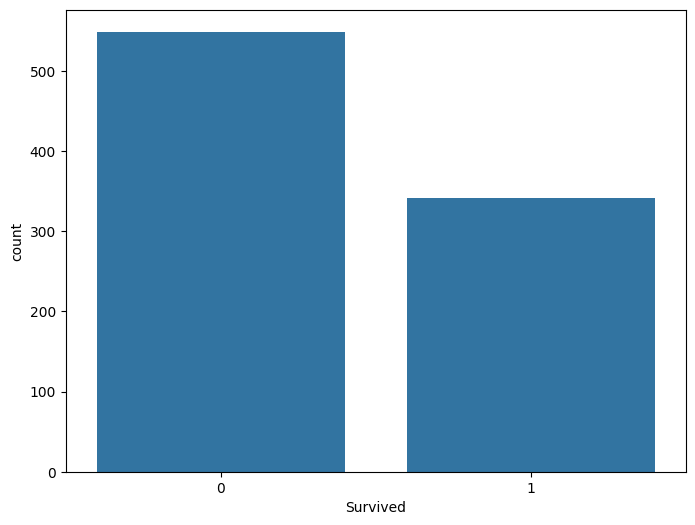

In [151]:
plt.figure(figsize=(8,6))
sns.countplot(x='Survived', data= train)

<Axes: xlabel='Survived', ylabel='count'>

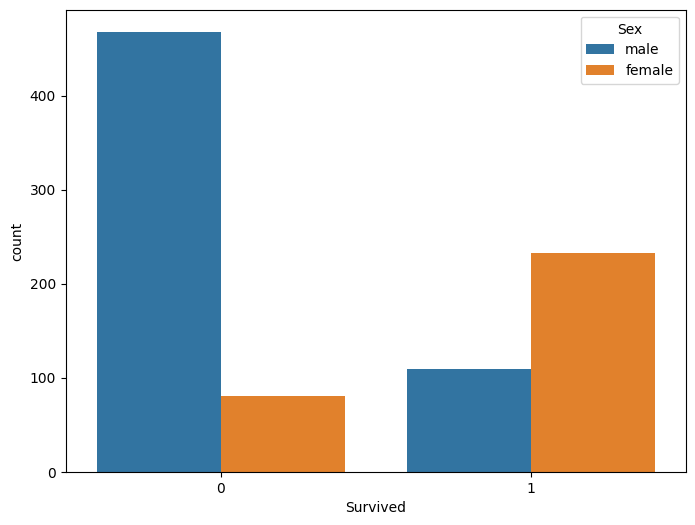

In [152]:
plt.figure(figsize=(8,6))
sns.countplot(x='Survived', hue='Sex', data= train)

<Axes: xlabel='Survived'>

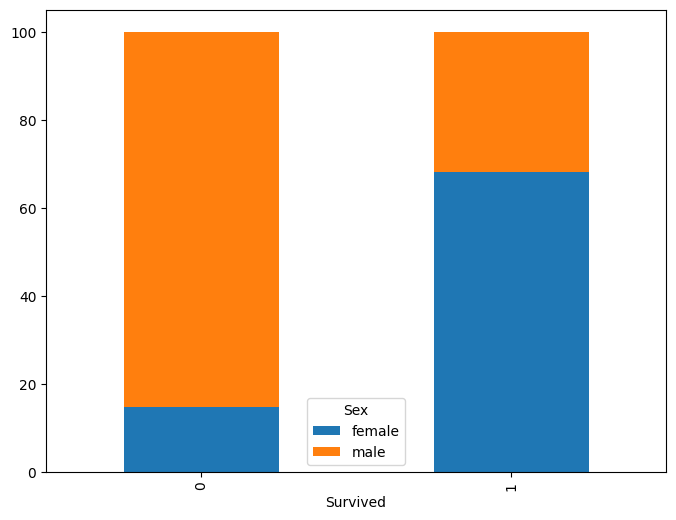

In [153]:
sur_p = train.groupby(['Survived', 'Sex']).size().unstack(fill_value=0)
sur_p_percent = sur_p.div(sur_p.sum(axis=1), axis=0) * 100
sur_p_percent.plot(kind='bar', stacked=True, figsize=(8,6))

<Axes: xlabel='Age', ylabel='Count'>

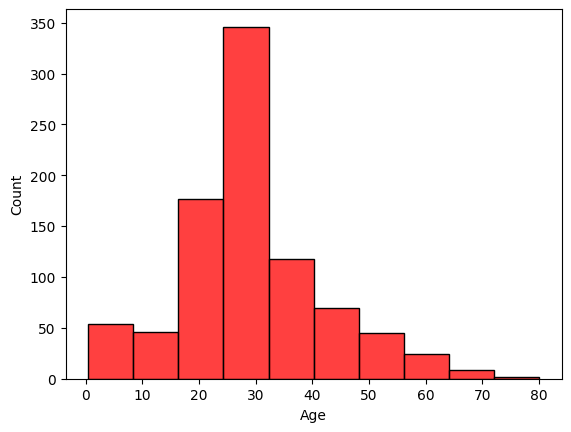

In [154]:
sns.histplot(x='Age', data=train, bins=10, color='red')

<Axes: xlabel='Pclass', ylabel='Fare'>

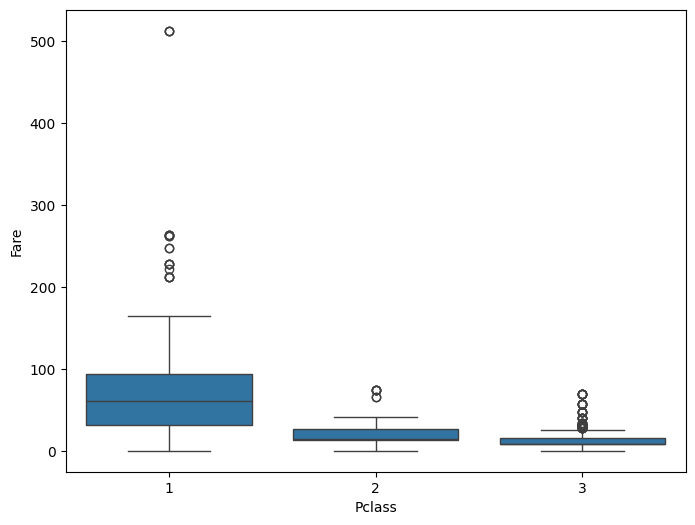

In [155]:
plt.figure(figsize=(8,6))
sns.boxplot(x='Pclass', y= 'Fare', data= train)

In [156]:
cols= ['Age', 'SibSp', 'Parch', 'Fare']

train[cols]= train[cols].clip(lower= train[cols].quantile(0.15), upper= train[cols].quantile(0.85), axis=1)

train.drop(columns=['Parch'], axis=1, inplace=True)

In [157]:
train.select_dtypes(include='number').corr()

,Survived,Pclass,Age,SibSp,Fare
Survived,1.000000,-0.338481,-0.023878,0.115867,0.314835
Pclass,-0.338481,1.000000,-0.333720,-0.076009,-0.726347
Age,-0.023878,-0.333720,1.000000,-0.079553,0.167626
SibSp,0.115867,-0.076009,-0.079553,1.000000,0.394485
Fare,0.314835,-0.726347,0.167626,0.394485,1.000000


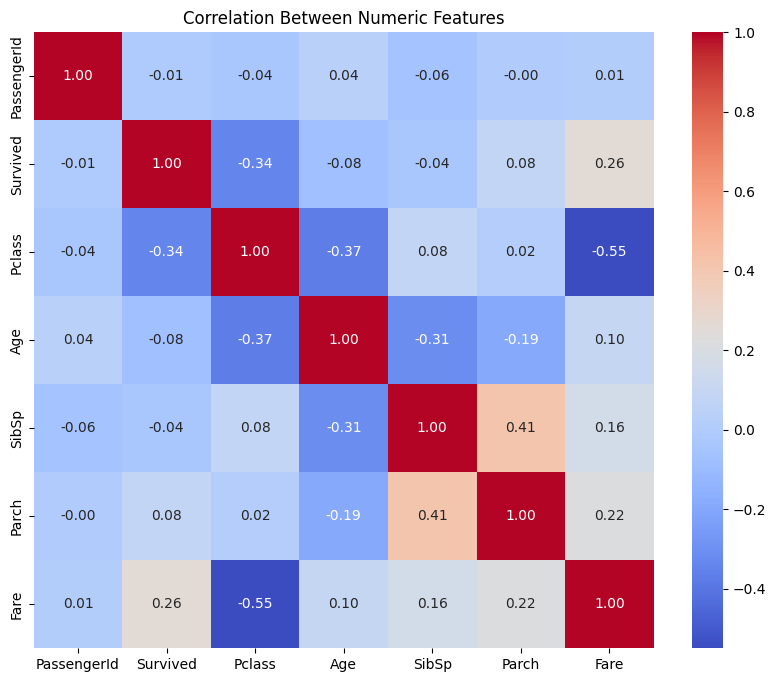

In [158]:
# Correlation heatmap of numeric features
plt.figure(figsize=(10, 8))
numeric_data = train_data.select_dtypes(include=['float64', 'int64'])
correlation = numeric_data.corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Between Numeric Features')
plt.savefig('correlation_heatmap.png')
plt.show()


<Axes: >

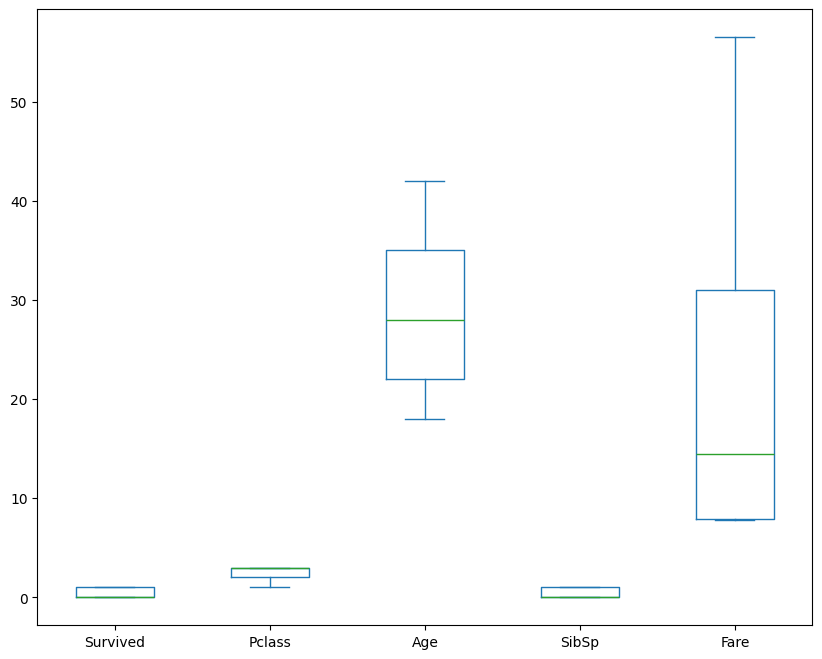

In [159]:
train.plot(kind='box', figsize= (10,8)) 

In [160]:
test[cols]= test[cols].clip(lower= test[cols].quantile(0.15), upper= test[cols].quantile(0.85), axis=1)

test.drop(columns=['Parch'], axis=1, inplace=True)

In [161]:
train= pd.get_dummies(train, columns=['Pclass', 'Sex', 'Embarked' ], drop_first= True)

test= pd.get_dummies(test, columns=['Pclass', 'Sex', 'Embarked' ], drop_first= True)

In [162]:
train.head()

,Survived,Age,SibSp,Fare,Pclass_2,Pclass_3,Sex_male,Embarked_Q,Embarked_S
0,0,22.0,1,7.7500,False,True,True,False,True
1,1,38.0,1,56.4958,False,False,False,False,False
2,1,26.0,0,7.9250,False,True,False,False,True
3,1,35.0,1,53.1000,False,False,False,False,True
4,0,35.0,0,8.0500,False,True,True,False,True


In [163]:
X_train= train.iloc[:, 1:]
y_train= train.iloc[:,0].values.reshape(-1,1)

X_test= test

In [164]:
from sklearn.preprocessing import StandardScaler
ss= StandardScaler()
features= ['Age', 'SibSp', 'Fare']

X_train[features]= ss.fit_transform(X_train[features])
X_test[features]= ss.fit_transform(X_test[features])

In [165]:
from sklearn.linear_model import LogisticRegression

clf= LogisticRegression()

clf.fit(X_train, y_train.ravel())

predictions= clf.predict(X_test)

In [166]:
print(clf.score(X_train, y_train))

0.792368125701459


In [167]:
cross_val_score(clf, X_train, y_train.ravel(), cv= 5).mean()

0.7834097043500095

In [168]:
# Ensure test_df is defined and available
submission = pd.DataFrame({'PassengerId': test_df['PassengerId'], 'Survived': predictions})

# Display the first few rows of the submission dataframe
print(submission.head())

   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         1


In [169]:
submission.to_csv('submission.csv', index= False)

In [170]:
model_cls = lightgbm.LGBMClassifier()

In [171]:
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1]
}

In [172]:
results = GridSearchCV(estimator=model_cls, param_grid=param_grid, scoring='accuracy', cv=5, verbose=1, n_jobs=-1)

In [173]:
results.fit(X_train, y_train.ravel())

Fitting 5 folds for each of 4 candidates, totalling 20 fits
[LightGBM] [Info] Number of positive: 342, number of negative: 549
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000230 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 129
[LightGBM] [Info] Number of data points in the train set: 891, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.383838 -> initscore=-0.473288
[LightGBM] [Info] Start training from score -0.473288
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [War

GridSearchCV(cv=5, estimator=LGBMClassifier(), n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1],
                         'n_estimators': [100, 200]},
             scoring='accuracy', verbose=1)

In [174]:
display(results.best_params_)

{'learning_rate': 0.1, 'n_estimators': 100}

In [175]:
model = display(results.best_estimator_)

LGBMClassifier()

In [176]:
display(results.best_score_)

0.8282907538760906

In [177]:

import optuna
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Objective function for Optuna
def objective(trial):
    param = {
        "objective": "binary",
        "metric": "binary_error",
        "verbosity": -1,
        "boosting_type": "gbdt",
        "feature_pre_filter": False,
        "lambda_l1": trial.suggest_float("lambda_l1", 1e-8, 10.0, log=True),
        "lambda_l2": trial.suggest_float("lambda_l2", 1e-8, 10.0, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 2, 256),
        "feature_fraction": trial.suggest_float("feature_fraction", 0.4, 1.0),
        "bagging_fraction": trial.suggest_float("bagging_fraction", 0.4, 1.0),
        "bagging_freq": trial.suggest_int("bagging_freq", 1, 7),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(
        lgb.LGBMClassifier(**param),
        X_train, y_train,
        scoring="accuracy",
        cv=cv,
        n_jobs=-1
    )

    return 1.0 - scores.mean()  # minimize error (maximize accuracy)

# Run Optuna optimization
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50)

# Show best trial
print("Best trial:")
trial = study.best_trial
print(f"  Accuracy: {1 - trial.value:.4f}")
print("  Best hyperparameters: ")
for key, value in trial.params.items():
    print(f"    {key}: {value}")

[I 2025-04-22 12:14:06,882] A new study created in memory with name: no-name-2fcc8a0d-4124-4b45-90cb-c6eb931749c1
[I 2025-04-22 12:14:07,298] Trial 0 finished with value: 0.19418743330613264 and parameters: {'lambda_l1': 0.010163878060806883, 'lambda_l2': 7.794323627442902e-08, 'num_leaves': 79, 'feature_fraction': 0.4762129912719557, 'bagging_fraction': 0.7091707829015528, 'bagging_freq': 7, 'min_child_samples': 9}. Best is trial 0 with value: 0.19418743330613264.
[I 2025-04-22 12:14:07,517] Trial 1 finished with value: 0.17620362814638124 and parameters: {'lambda_l1': 2.5775149436388336, 'lambda_l2': 1.3605529556370427e-06, 'num_leaves': 240, 'feature_fraction': 0.8552722148424904, 'bagging_fraction': 0.9241265633266426, 'bagging_freq': 4, 'min_child_samples': 17}. Best is trial 1 with value: 0.17620362814638124.
[I 2025-04-22 12:14:07,734] Trial 2 finished with value: 0.18633481890653447 and parameters: {'lambda_l1': 3.712650793062225e-05, 'lambda_l2': 4.225745079562491e-06, 'num_le

Best trial:
  Accuracy: 0.8294
  Best hyperparameters: 
    lambda_l1: 1.3502938047330863e-07
    lambda_l2: 2.288560214166073e-05
    num_leaves: 244
    feature_fraction: 0.8520249680079602
    bagging_fraction: 0.8498254238663471
    bagging_freq: 5
    min_child_samples: 19


In [178]:
all_df = pd.concat([train_df, test_df], axis=0)
all_df["set"] = "train"
all_df.loc[all_df.Survived.isna(), "set"] = "test"

In [179]:
all_df["Family Size"] = all_df["SibSp"] + all_df["Parch"] + 1
all_df["Age Interval"] = 0.0
all_df.loc[ all_df['Age'] <= 16, 'Age Interval']  = 0
all_df.loc[(all_df['Age'] > 16) & (all_df['Age'] <= 32), 'Age Interval'] = 1
all_df.loc[(all_df['Age'] > 32) & (all_df['Age'] <= 48), 'Age Interval'] = 2
all_df.loc[(all_df['Age'] > 48) & (all_df['Age'] <= 64), 'Age Interval'] = 3
all_df.loc[ all_df['Age'] > 64, 'Age Interval'] = 4
all_df['Fare Interval'] = 0.0
all_df.loc[ all_df['Fare'] <= 7.91, 'Fare Interval'] = 0
all_df.loc[(all_df['Fare'] > 7.91) & (all_df['Fare'] <= 14.454), 'Fare Interval'] = 1
all_df.loc[(all_df['Fare'] > 14.454) & (all_df['Fare'] <= 31), 'Fare Interval']   = 2
all_df.loc[ all_df['Fare'] > 31, 'Fare Interval'] = 3
all_df["Sex_Pclass"] = all_df.apply(lambda row: row['Sex'][0].upper() + "_C" + str(row["Pclass"]), axis=1)
def get_deck(text):
    try:
        return text[0]
    except Exception as ex:
        return "Unknown"
    
all_df["Deck"] = all_df["Cabin"].apply(lambda x: get_deck(x))

In [180]:
def parse_names(row):
    try:
        text = row["Name"]
        split_text = text.split(",")
        family_name = split_text[0]
        next_text = split_text[1]
        split_text = next_text.split(".")
        title = (split_text[0] + ".").lstrip().rstrip()
        next_text = split_text[1]
        if "(" in next_text:
            split_text = next_text.split("(")
            given_name = split_text[0]
            maiden_name = split_text[1].rstrip(")")
            return pd.Series([family_name, title, given_name, maiden_name])
        else:
            given_name = next_text
            return pd.Series([family_name, title, given_name, None])
    except Exception as ex:
        print(f"Exception: {ex}")
    
all_df[["Family Name", "Title", "Given Name", "Maiden Name"]] = all_df.apply(lambda row: parse_names(row), axis=1)

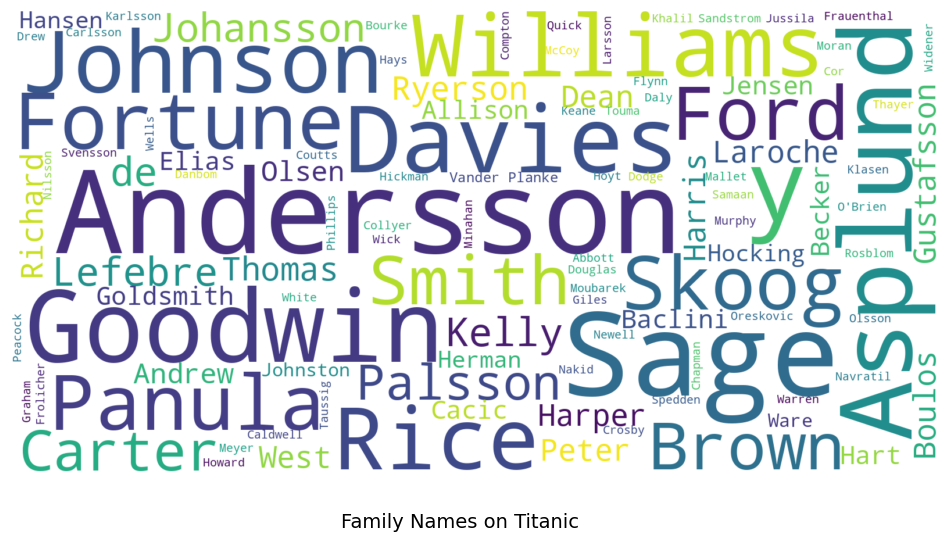

In [181]:
from wordcloud import WordCloud, STOPWORDS
stopwords = set(STOPWORDS)

def show_wordcloud(data, mask=None, title=""):
    text = " ".join(t for t in data.dropna())
    stopwords = set(STOPWORDS)
    stopwords.update(["t", "co", "https", "amp", "U", "Comment", "text", "attr", "object"])
    wordcloud = WordCloud(stopwords=stopwords, scale=4, max_font_size=50, max_words=500,mask=mask, background_color="white").generate(text)
    fig = plt.figure(1, figsize=(12, 12))
    plt.axis('off')
    fig.suptitle(title, fontsize=14)
    fig.subplots_adjust(top=2.3)
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.show()    
show_wordcloud(all_df["Family Name"], title="Family Names on Titanic")

In [182]:
all_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,set,Family Size,Age Interval,Fare Interval,Sex_Pclass,Deck,Family Name,Title,Given Name,Maiden Name
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,...,train,2,1.0,0.0,M_C3,Unknown,Braund,Mr.,Owen Harris,None
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,...,train,2,2.0,3.0,F_C1,C,Cumings,Mrs.,John Bradley,Florence Briggs Thayer
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,...,train,1,1.0,1.0,F_C3,Unknown,Heikkinen,Miss.,Laina,None
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,...,train,2,2.0,3.0,F_C1,C,Futrelle,Mrs.,Jacques Heath,Lily May Peel
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,...,train,1,2.0,1.0,M_C3,Unknown,Allen,Mr.,William Henry,None


In [183]:
all_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1309 entries, 0 to 417
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   PassengerId    1309 non-null   int64  
 1   Survived       891 non-null    float64
 2   Pclass         1309 non-null   int64  
 3   Name           1309 non-null   object 
 4   Sex            1309 non-null   object 
 5   Age            1046 non-null   float64
 6   SibSp          1309 non-null   int64  
 7   Parch          1309 non-null   int64  
 8   Ticket         1309 non-null   object 
 9   Fare           1308 non-null   float64
 10  Cabin          295 non-null    object 
 11  Embarked       1307 non-null   object 
 12  set            1309 non-null   object 
 13  Family Size    1309 non-null   int64  
 14  Age Interval   1309 non-null   float64
 15  Fare Interval  1309 non-null   float64
 16  Sex_Pclass     1309 non-null   object 
 17  Deck           1309 non-null   object 
 18  Family Name   

In [184]:
# Print number of unique values in each column
print("\nUnique values in each column:")
print(all_df.nunique())


Unique values in each column:
PassengerId      1309
Survived            2
Pclass              3
Name             1307
Sex                 2
Age                98
SibSp               7
Parch               8
Ticket            929
Fare              281
Cabin             186
Embarked            3
set                 2
Family Size         9
Age Interval        5
Fare Interval       4
Sex_Pclass          6
Deck                9
Family Name       875
Title              18
Given Name       1083
Maiden Name       220
dtype: int64


In [185]:
print(all_df.isnull().sum())

PassengerId         0
Survived          418
Pclass              0
Name                0
Sex                 0
Age               263
SibSp               0
Parch               0
Ticket              0
Fare                1
Cabin            1014
Embarked            2
set                 0
Family Size         0
Age Interval        0
Fare Interval       0
Sex_Pclass          0
Deck                0
Family Name         0
Title               0
Given Name          0
Maiden Name      1088
dtype: int64


In [186]:
all_df["Age"].fillna(all_df["Age"].median(), inplace=True)
all_df["Maiden Name"].fillna("Unknown", inplace=True)
all_df["Cabin"].fillna("Unknown", inplace=True)

C:\Users\qli97\AppData\Local\Temp\ipykernel_23048\3357642764.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  all_df["Age"].fillna(all_df["Age"].median(), inplace=True)
C:\Users\qli97\AppData\Local\Temp\ipykernel_23048\3357642764.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy

In [187]:
#Columns with unique values that are more than 200

unique_counts = all_df.nunique()
unique_columns = unique_counts[unique_counts > 200].index.tolist()
dropped_all_df = all_df.drop(columns=unique_columns + ["set", "Survived"])

cat_columns = dropped_all_df.select_dtypes(include=["object"]).columns.tolist()
dummy_all_df = pd.get_dummies(dropped_all_df, columns=cat_columns, drop_first=True)

In [188]:

X_train = dummy_all_df[all_df["set"] == "train"]
X_test = dummy_all_df[all_df["set"] == "test"]
y_train = all_df[all_df["set"] == "train"]["Survived"]
y_test = all_df[all_df["set"] == "test"]["Survived"]

In [189]:
from sklearn.linear_model import LogisticRegression

clf= LogisticRegression()

clf.fit(X_train, y_train.ravel())

predictions= clf.predict(X_test)

C:\Users\qli97\AppData\Local\Temp\ipykernel_23048\59125972.py:5: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  clf.fit(X_train, y_train.ravel())
f:\Anaconda\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [190]:
print(clf.score(X_train, y_train))

cross_val_score(clf, X_train, y_train, cv= 5).mean()


0.8709315375982043


f:\Anaconda\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
f:\Anaconda\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result

0.8294520118008913

In [191]:

model_cls = lightgbm.LGBMClassifier()

param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1]
}

results = GridSearchCV(estimator=model_cls, param_grid=param_grid, scoring='accuracy', cv=5, verbose=1, n_jobs=-1)


results.fit(X_train, y_train.ravel())

display(results.best_score_)

C:\Users\qli97\AppData\Local\Temp\ipykernel_23048\2450199240.py:11: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  results.fit(X_train, y_train.ravel())


Fitting 5 folds for each of 4 candidates, totalling 20 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 342, number of negative: 549
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000817 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 138
[LightGBM] [Info] Number of data points in the train set: 891, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.383838 -> initscore=-0.473288
[LightGBM] [Info] Start training from score -0.473288
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


0.839539263071998